Loading IMDB dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (25000, 200)
Test Data Shape: (25000, 200)

Training Simple RNN
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.6487 - loss: 0.6065 - val_accuracy: 0.7244 - val_loss: 0.5383
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.8280 - loss: 0.3964 - val_accuracy: 0.8236 - val_loss: 0.4078
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.8298 - loss: 0.3964 - val_accuracy: 0.7282 - val_loss: 0.5362

Training LSTM
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 175ms/step - accuracy: 0.7793 - loss: 0.4617 - val_accuracy: 0.8522 - val_loss: 0.3564
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 174ms/step - accuracy: 0.8938 - loss: 0.2689 - val_accuracy: 0.8440 - val_loss: 0.3605
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.9226 - loss: 0.2061 - val_accuracy: 0.8512 - val_loss: 0.3453

Training GRU
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 203ms/step - accuracy: 0.7619 - loss: 0.4676 - val_accuracy: 0.8542 - val_loss: 0.3410
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 207ms/step - accuracy: 0.8946 -

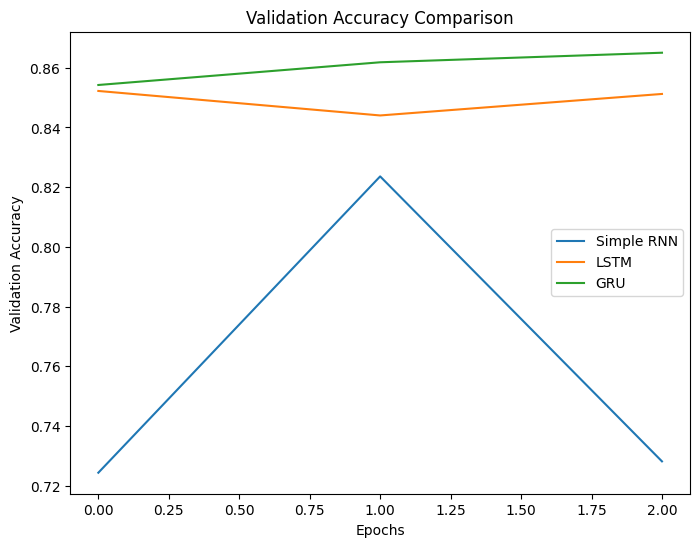

In [1]:
# ===============================
# Lab 4: RNN vs LSTM vs GRU
# ===============================

import numpy as np
import tensorflow as tf
import time
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam

# ===============================
# 1️⃣ Load Dataset
# ===============================

vocab_size = 10000
max_length = 200

print("Loading IMDB dataset...")

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding sequences
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

# ===============================
# 2️⃣ Build Models
# ===============================

def build_rnn():
    model = Sequential()
    model.add(Embedding(vocab_size, 64, input_length=max_length))
    model.add(SimpleRNN(64))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(),
                  metrics=['accuracy'])
    return model


def build_lstm():
    model = Sequential()
    model.add(Embedding(vocab_size, 64, input_length=max_length))
    model.add(LSTM(64))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(),
                  metrics=['accuracy'])
    return model


def build_gru():
    model = Sequential()
    model.add(Embedding(vocab_size, 64, input_length=max_length))
    model.add(GRU(64))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(),
                  metrics=['accuracy'])
    return model


# ===============================
# 3️⃣ Train Models
# ===============================

models = {
    "Simple RNN": build_rnn(),
    "LSTM": build_lstm(),
    "GRU": build_gru()
}

results = {}
history_dict = {}

for name, model in models.items():
    print("\n==============================")
    print(f"Training {name}")
    print("==============================")

    start_time = time.time()

    history = model.fit(X_train, y_train,
                        epochs=3,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)

    end_time = time.time()

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results[name] = {
        "Test Accuracy": accuracy,
        "Test Loss": loss,
        "Training Time": end_time - start_time
    }

    history_dict[name] = history


# ===============================
# 4️⃣ Print Final Comparison
# ===============================

print("\n\n========== FINAL RESULTS ==========\n")

for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"Test Accuracy: {metrics['Test Accuracy']:.4f}")
    print(f"Test Loss: {metrics['Test Loss']:.4f}")
    print(f"Training Time: {metrics['Training Time']:.2f} seconds")
    print("------------------------------------")


# ===============================
# 5️⃣ Plot Accuracy Graph
# ===============================

plt.figure(figsize=(8,6))

for name in history_dict:
    plt.plot(history_dict[name].history['val_accuracy'], label=name)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()